# Defense Industry Primer: European Nuclear Expansion & Equity Implications


In [1]:
# import yfinance as yf
# import pandas as pd

# tickers = [
#     "AIR.PA", "HO.PA", "SAF.PA",
#     "RHM.DE", "LDO.MI", "SAAB-B.ST",
#     "BA.L", "RR.L",
#     "LMT", "NOC", "RTX", "GD",
#     "TDY", "LHX", "KOG.OL"
# ]

# data = yf.download(
#     tickers,
#     start="2018-01-01",
#     auto_adjust=True
# )["Close"]

# data.tail()

import yfinance as yf
import pandas as pd, numpy as np


tickers = [
 "EGRI.PA" ,"^STOXX"  
]

data = yf.download(
    tickers,
    start="2018-01-01",
    auto_adjust=True
)["Close"]

data.tail()

[*********************100%***********************]  2 of 2 completed


Ticker,EGRI.PA,^STOXX
Date,,
2026-03-05,45.875000,604.830017
2026-03-06,45.779999,598.690002
2026-03-09,45.669998,594.919983
2026-03-10,45.895000,606.119995
2026-03-11,45.689999,600.609985


In [2]:
data.shape

(2082, 2)

In [3]:
data.dropna().resample('ME').last()


Ticker,EGRI.PA,^STOXX
Date,,
2020-07-31,50.490002,356.329987
2020-08-31,50.160000,366.510010
2020-09-30,50.720001,361.089996
2020-10-31,51.110001,342.359985
2020-11-30,51.240002,389.359985
...,...,...
2025-11-30,45.794998,576.429993
2025-12-31,45.549999,592.780029
2026-01-31,45.880001,611.000000


In [4]:
# log returns
log_returns = np.log(data / data.shift(1)).dropna()

In [5]:

log_returns.shape

(1406, 2)

In [6]:

from simulator import LifecycleParameters, HistoricalBootstrapSimulator,CPPIEngine,MarketSimulator,StrategyParameters
import numpy as np

p = LifecycleParameters(
    current_age=30,
    starting_pot=50_000,
    n_simulations=500,
    time_horizon=43,  # years until retirement
    rebalance_freq="daily",

    
    
    
)

sim_returns = HistoricalBootstrapSimulator(p).generate_returns(seed=42,block_size=5)

In [7]:


params = StrategyParameters(
    initial_wealth=1_000_000,
    time_horizon=43,
    cppi_multiplier=3,
    floor_pct=80,
    expected_return=100*sim_returns["equity"].mean()*252,  # annualized mean return
    market_volatility=100*sim_returns["equity"].std() * np.sqrt(252),  # annualized volatility,
    risk_free_rate=2.0,
    n_simulations=500,
    rebalance_freq="daily",
    annual_withdrawal=40_000,
)


market = MarketSimulator(params)
log_returns = market.generate_returns(seed=42)

In [8]:
abs(log_returns.std() - sim_returns["equity"].std())

np.float64(1.5071531313526343e-06)

In [9]:
sim_returns["bond"][:,0]

array([ 0.00019511,  0.00058494, -0.00195119, ..., -0.00275164,
        0.00045915,  0.00103661], shape=(10836,))

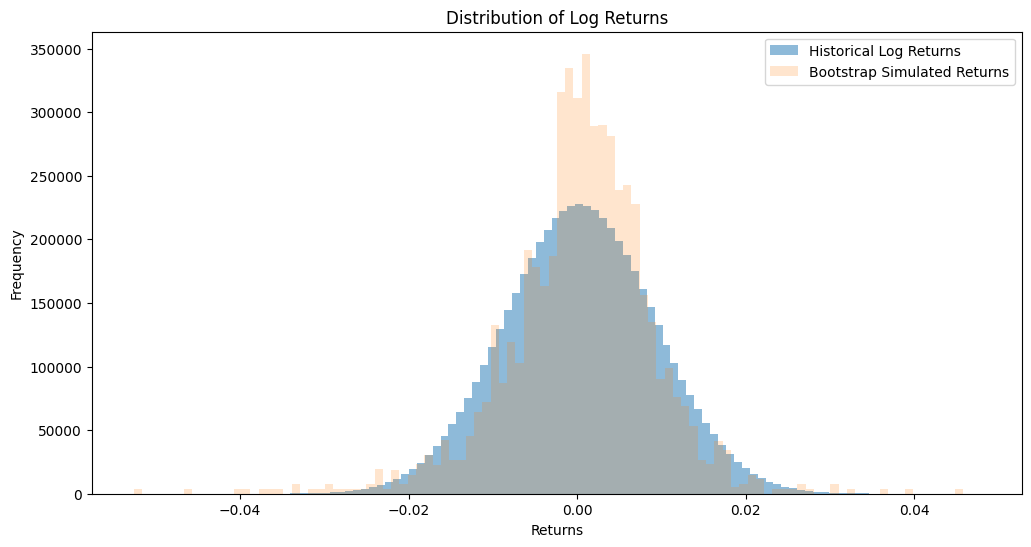

In [10]:
# hist of log returns and sim returns (numerical and bootstrap) for equity
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(log_returns.flatten(), bins=100, alpha=0.5, label="Historical Log Returns")
plt.hist(sim_returns["equity"].flatten(), bins=100, alpha=0.2,  label="Bootstrap Simulated Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.title("Distribution of Log Returns")
plt.legend()
plt.show()
  

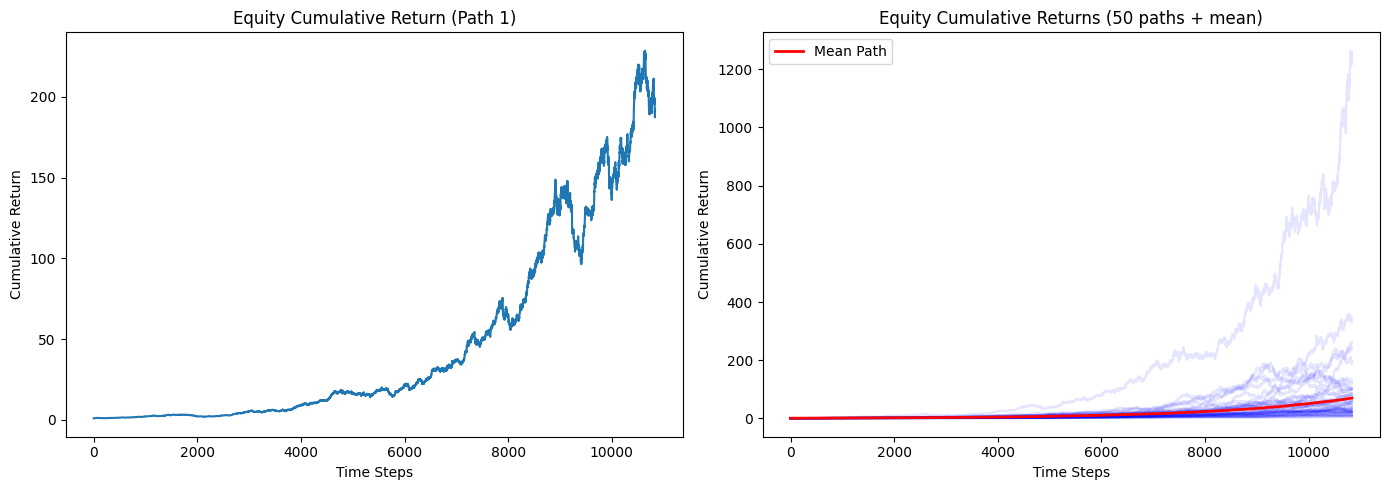

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equity cumulative return (path 1)
axes[0].plot(np.exp(sim_returns["equity"][:, 1].cumsum()))
axes[0].set_title("Equity Cumulative Return (Path 1)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Cumulative Return")

# All paths (faded) + mean path
cum_returns = np.exp(np.cumsum(sim_returns["equity"], axis=0))
axes[1].plot(cum_returns[:, :50], alpha=0.1, color="blue")
axes[1].plot(cum_returns.mean(axis=1), color="red", linewidth=2, label="Mean Path")
axes[1].set_title("Equity Cumulative Returns (50 paths + mean)")
axes[1].set_xlabel("Time Steps")
axes[1].set_ylabel("Cumulative Return")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:

sim_returns.keys()

dict_keys(['equity', 'bond'])

In [13]:
engine = CPPIEngine(params)
result = engine.run(sim_returns["equity"],sim_returns["bond"] ,)
print("using bootstrap sim returns (80% equity, 20% bond)")
print(f"portfolio_values  shape: {result.portfolio_values.shape}")
print(f"floor_values      shape: {result.floor_values.shape}")
print(f"risky_paths       shape: {result.risky_paths.shape}")
print(f"risky_allocation  shape: {result.risky_allocation.shape}")
print(f"withdrawals_made  shape: {result.withdrawals_made.shape}")
print(f"\nFinal portfolio value (path 0): ${result.portfolio_values[-1, 0]:,.2f}")
print(f"Final floor value             : ${result.floor_values[-1]:,.2f}")
print(f"Final risky benchmark (path 0): ${result.risky_paths[-1, 0]:,.2f}")
print(f"Final risky allocation (path 0): {result.risky_allocation[-1, 0]:.2%}")
print(f"Total withdrawals (path 0)     : ${result.withdrawals_made[:, 0].sum():,.2f}  (0; accumulation mode)")

using bootstrap sim returns (80% equity, 20% bond)
portfolio_values  shape: (10836, 500)
floor_values      shape: (10836,)
risky_paths       shape: (10836, 500)
risky_allocation  shape: (10836, 500)
withdrawals_made  shape: (10836, 500)

Final portfolio value (path 0): $0.00
Final floor value             : $0.00
Final risky benchmark (path 0): $59,949,516.21
Final risky allocation (path 0): 0.00%
Total withdrawals (path 0)     : $830,479.11  (0; accumulation mode)


In [55]:
engine = CPPIEngine(params)
result = engine.run(log_returns)

print(f"portfolio_values  shape: {result.portfolio_values.shape}")
print(f"floor_values      shape: {result.floor_values.shape}")
print(f"risky_paths       shape: {result.risky_paths.shape}")
print(f"risky_allocation  shape: {result.risky_allocation.shape}")
print(f"withdrawals_made  shape: {result.withdrawals_made.shape}")
print(f"\nFinal portfolio value (path 0): ${result.portfolio_values[-1, 0]:,.2f}")
print(f"Final floor value             : ${result.floor_values[-1]:,.2f}")
print(f"Final risky benchmark (path 0): ${result.risky_paths[-1, 0]:,.2f}")
print(f"Final risky allocation (path 0): {result.risky_allocation[-1, 0]:.2%}")
print(f"Total withdrawals (path 0)     : ${result.withdrawals_made[:, 0].sum():,.2f}  (0; accumulation mode)")

portfolio_values  shape: (10836, 500)
floor_values      shape: (10836,)
risky_paths       shape: (10836, 500)
risky_allocation  shape: (10836, 500)
withdrawals_made  shape: (10836, 500)

Final portfolio value (path 0): $0.00
Final floor value             : $0.00
Final risky benchmark (path 0): $147,183.57
Final risky allocation (path 0): 0.00%
Total withdrawals (path 0)     : $1,386,373.73  (0; accumulation mode)



## 1. European Prime Defense Contractors

Direct beneficiaries of European defense budgets.

| Company     | Role                                             | Ticker      |
| ----------- | ------------------------------------------------ | ----------- |
| Airbus      | Defense aircraft, satellites, military transport | `AIR.PA`    |
| Thales      | Radars, electronic warfare, missiles             | `HO.PA`     |
| Safran      | Military engines, guidance systems               | `SAF.PA`    |
| Rheinmetall | Ammunition, armored vehicles                     | `RHM.DE`    |
| Leonardo    | Helicopters, avionics, electronics               | `LDO.MI`    |
| Saab        | Fighter aircraft (Gripen), sensors               | `SAAB-B.ST` |
| BAE Systems | Nuclear submarines, combat systems               | `BA.L`      |

Why these:
European governments typically **buy from domestic champions** for sovereignty reasons. When budgets expand, these companies receive the orders first.





## 2. Nuclear Deterrence / Submarine Industrial Base

More tightly linked to **France + UK nuclear programs**.

| Company                  | Role                         | Ticker |
| ------------------------ | ---------------------------- | ------ |
| BAE Systems              | UK nuclear submarine builder | `BA.L` |
| Rolls-Royce              | Nuclear submarine propulsion | `RR.L` |
| Naval Group (not listed) | French submarines            |;      |

Note: **France’s deterrence program is largely state-controlled**, so equity exposure is indirect via suppliers like **Thales and Safran**.





## 3. US Strategic Weapons & Missiles

These often move when **global tensions rise**, even if spending is European.

| Company          | Role                  | Ticker |
| ---------------- | --------------------- | ------ |
| Lockheed Martin  | Missile defense, F-35 | `LMT`  |
| Northrop Grumman | Nuclear bomber B-21   | `NOC`  |
| RTX (Raytheon)   | Missile systems       | `RTX`  |
| General Dynamics | Nuclear submarines    | `GD`   |

Markets frequently react faster to US contractors because they have **higher liquidity and global exposure**.





## 4. Military Electronics & Sensors

Critical bottleneck technologies.

| Company   | Role                          | Ticker   |
| --------- | ----------------------------- | -------- |
| Teledyne  | Defense sensors, imaging      | `TDY`    |
| L3Harris  | communication systems         | `LHX`    |
| Kongsberg | missiles, defense electronics | `KOG.OL` |





## 5. Ammunition / Ground Warfare Surge

These reacted strongly after Ukraine.

| Company     | Role                   | Ticker   |
| ----------- | ---------------------- | -------- |
| Rheinmetall | artillery & ammunition | `RHM.DE` |
| BAE Systems | artillery production   | `BA.L`   |



# Portfolio Construction


In [2]:
returns = data.pct_change().dropna()

weights = [1/len(tickers)] * len(tickers)

portfolio_returns = returns.dot(weights)

portfolio = (1 + portfolio_returns).cumprod()

portfolio.tail()

C:\Users\amine\AppData\Local\Temp\ipykernel_10264\1792489905.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


Date
2026-03-02    5.908820
2026-03-03    5.795165
2026-03-04    5.886998
2026-03-05    5.678666
2026-03-06    5.748512
dtype: float64

[*********************100%***********************]  1 of 1 completed


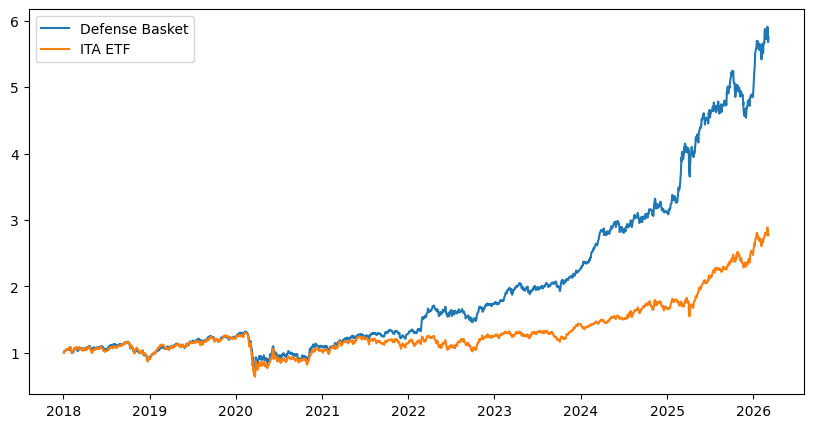

In [3]:
benchmark = yf.download("ITA", start="2018-01-01", auto_adjust=True)["Close"]

benchmark_returns = benchmark.pct_change().dropna()
benchmark_curve = (1 + benchmark_returns).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(portfolio, label="Defense Basket")
plt.plot(benchmark_curve, label="ITA ETF")
plt.legend()
plt.show()

In [4]:
benchmark_curve['ITA']

Date
2018-01-03    1.001486
2018-01-04    1.008491
2018-01-05    1.017566
2018-01-08    1.023722
2018-01-09    1.030303
                ...   
2026-03-02    2.887057
2026-03-03    2.822537
2026-03-04    2.845464
2026-03-05    2.765620
2026-03-06    2.771957
Name: ITA, Length: 2054, dtype: float64

<Axes: xlabel='Date'>

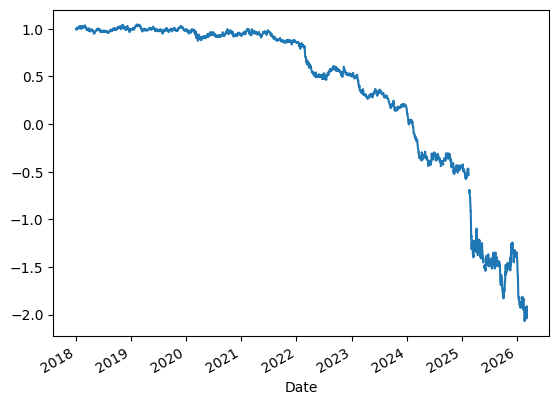

In [5]:
portfolio_t = 1+ (-portfolio+benchmark_curve['ITA'])
portfolio_t.plot()

# Ref code

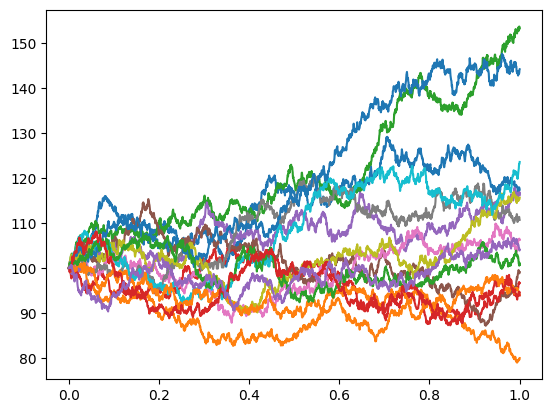

In [6]:
# -*- coding: utf-8 -*-
"""
Created on Thu Apr 15 16:14:54 2021

@author: turinici
"""
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

T=1.0
#N=52
N=255*8
M=3000 # nombre de scenarios
dt = T/N
W0=0

timerange = np.linspace(0,T,N+1,endpoint=True)
timerange=timerange[:,None]
dW= np.sqrt(dt)*np.random.randn(N,M)

W=np.zeros((N+1,M)) 
W[0,:]=W0
W[1:,:]=W0+np.cumsum(dW,0)

S0=100.
mu=0.1
sigma=0.15
taux_r=0.03

def st(mu,sigma,t,wt):
    return np.exp((mu-sigma**2/2.)*t + sigma*wt)

St = st(mu,sigma,timerange,W)*S0

plt.figure(1)
for ii in range(15):
    plt.plot(timerange,St[:,ii])


In [7]:

V0=1000
P0=950
m=5
Pt=np.zeros(N+1)
Pt[0]=P0
Ct=np.zeros_like(St)
Xt=np.zeros_like(St)
Mt=np.zeros_like(St)
Vt=np.zeros_like(St)

#mise en place de la strategie
Vt[0,:]=V0
Pt[0]=P0
Ct[0,:]=V0-P0
Xt[0,:]=m*Ct[0,:]
Mt[0,:]=Vt[0,:]-Xt[0,:]


for jj in range(N):
    Pt[jj+1] =Pt[jj]*np.exp(taux_r*dt)#actualisation de P
    Mt[jj+1,:] =Mt[jj,:]*np.exp(taux_r*dt)#actualisation de M
    Xt[jj+1,:] =Xt[jj,:]*St[jj+1,:]/St[jj,:]#mise a jour partie risquee avec St
    Vt[jj+1,:] =Xt[jj+1,:]+Mt[jj+1,:] # calcul de valeur du portfeuille
    Ct[jj+1,:] =Vt[jj+1,:]-Pt[jj+1] #calcul du coussin

    # re-allocation selon les prescriptions de la regle CPPI:
    Xt[jj+1,:]=m*Ct[jj+1,:]
    Mt[jj+1,:]=Vt[jj+1,:]-Xt[jj+1,:]
    
    


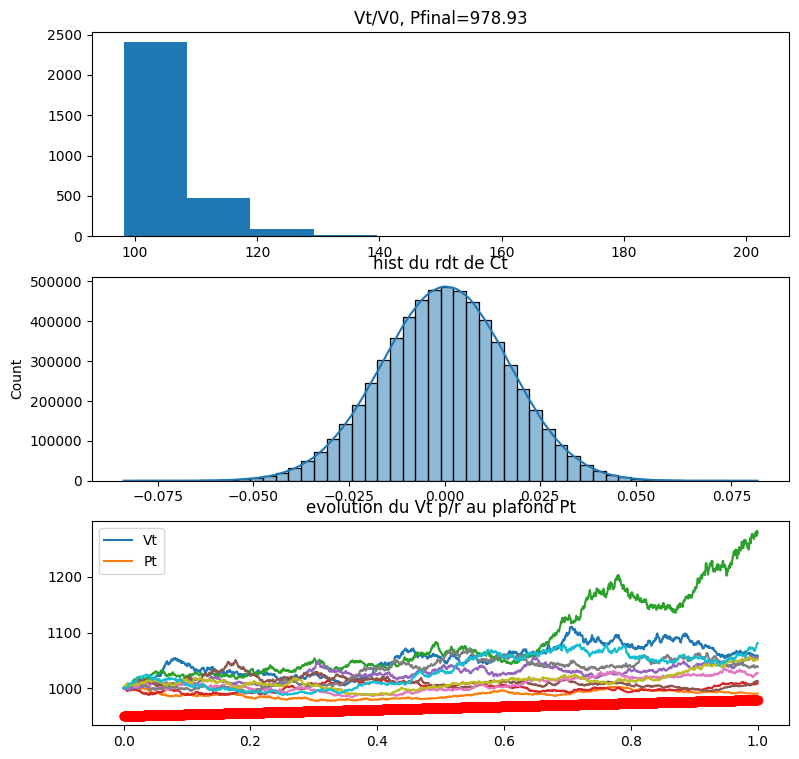

In [10]:
#livraison
cash = Xt[-1,:]+Mt[-1,:] # calcul de la valeur finale

plt.figure(10,figsize=(9, 9))
plt.subplot(3,1,1)
plt.hist(cash*100/V0)
plt.title('Vt/V0, Pfinal='+str(np.round(Pt[-1],2)))

plt.subplot(3,1,2)
r_ct = (Ct[1:, :] / Ct[:-1, :]).ravel()
log_r_ct = np.log(r_ct[r_ct > 0])  # keep valid values for log

sns.histplot(log_r_ct, bins=50, kde=True)
plt.title('hist du rdt de Ct')

plt.subplot(3,1,3)
#plt.figure(9)
plt.title('evolution du Vt p/r au plafond Pt')
plt.plot(timerange,Vt[:,0:10])
plt.plot(timerange,Pt,'-ro')
plt.legend(['Vt','Pt'])
   
    
    

# Manual code

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
T=1
N=255*8 # nombre de pas de temps 8
scenarios=3000 # nombre de scenarios
dt = T/N
W0=0


timerange = np.linspace(0,T,N+1,endpoint=True).reshape(-1, 1)
dW= np.sqrt(dt)*np.random.randn(N,scenarios)

W= np.zeros((N+1,scenarios))
W[0,:]=W0
W[1:,:]=W0+np.cumsum(dW,0)

S0=100.
mu=0.1
sigma=0.15
taux_r=0.03

def St(mu,sigma,t,wt):
    return np.exp((mu-sigma**2/2.)*t + sigma*wt)
S = St(mu,sigma,timerange,W)






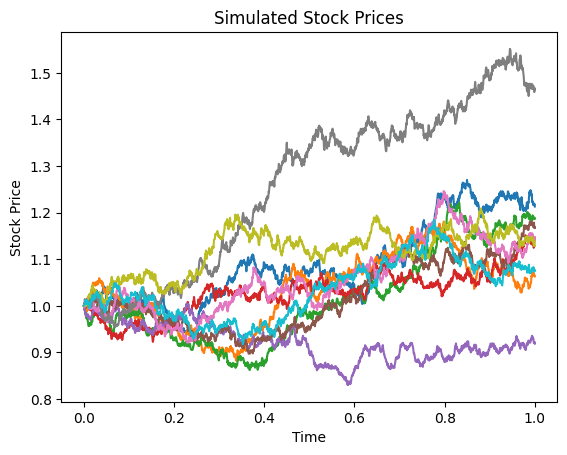

In [14]:
plt.plot(timerange, S[:, :10]) # plot the first 10 scenarios
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Simulated Stock Prices')
plt.show()

In [76]:
V0=1000

P0=950

m=2

Pt=np.zeros(N+1)
Pt[0]=P0
Ct=np.zeros_like(S)
Xt=np.zeros_like(S)
Mt=np.zeros_like(S)
Vt=np.zeros_like(S)
Vt[0,:] = V0
Pt[0] = P0

Ct[0,:] = V0-P0
Xt[0,:] = m*(V0-P0)
Mt[0,:] = Vt[0,:] - Xt[0,:]

for t_step in range(N):
    Pt[t_step+1] = np.exp(taux_r*dt)*Pt[t_step]
    Mt[t_step+1,:] = Mt[t_step,:]*np.exp(taux_r*dt)
    Xt[t_step+1,:]= Xt[t_step,:]*S[t_step+1,:]/S[t_step,:] 
    
    Vt[t_step+1,:] = Xt[t_step+1,:]+Mt[t_step+1,:]
    Ct[t_step+1,:] = Vt[t_step+1,:] - Pt[t_step+1] 
    
    Xt[t_step+1,:] = m*Ct[t_step+1,:]
    Mt[t_step+1,:] = Vt[t_step+1,:] - Xt[t_step+1,:]


cash = Xt[-1,:]+Mt[-1,:] # calcul de la valeur finale
cash

array([1000., 1000., 1000., ..., 1000., 1000., 1000.], shape=(3000,))

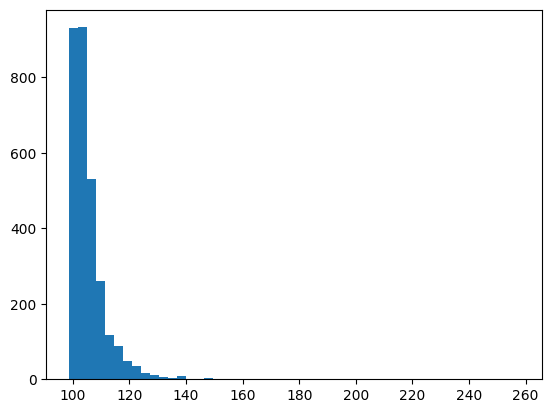

In [82]:
plt.hist(cash*100/V0, bins=50);

In [18]:
V0_f=1000

P0_f=950

m=2

Pt_f=np.zeros(N+1)
Pt_f[0]=P0_f
Ct_f=np.zeros_like(S)
Xt_f=np.zeros_like(S)
Mt_f=np.zeros_like(S)
Vt_f=np.zeros_like(S)
Vt_f[0,:] = V0_f
Pt_f[0] = P0_f

Ct_f[0,:] = V0_f-P0_f
Xt_f[0,:] = m*(V0_f-P0_f)
Mt_f[0,:] = Vt_f[0,:] - Xt_f[0,:]


t = np.arange(N + 1)
Pt_f = Pt_f[0] * np.exp(taux_r * dt * t)
exprdt= np.exp(taux_r*dt)
returns = S[1:] / S[:-1]
for t_step in range(N):
    Mt_f[t_step+1,:] = Mt_f[t_step,:]*exprdt
    Xt_f[t_step+1,:]= Xt_f[t_step,:]*returns[t_step,:] 
    
    Vt_f[t_step+1,:] = Xt_f[t_step+1,:]+Mt_f[t_step+1,:]
    Ct_f[t_step+1,:] = Vt_f[t_step+1,:] - Pt_f[t_step+1] 
    
    Xt_f[t_step+1,:] = m*Ct_f[t_step+1,:]
    Mt_f[t_step+1,:] = Vt_f[t_step+1,:] - Xt_f[t_step+1,:]

In [ ]:
from numba import njit

@njit 
def run_simulation(N, m, exprdt, returns, Pt_f, Mt_f, Xt_f, Vt_f, Ct_f):
    for t_step in range(N):
        Mt_f[t_step+1, :] = Mt_f[t_step, :] * exprdt
        Xt_f[t_step+1, :] = Xt_f[t_step, :] * returns[t_step, :] 
        
        Vt_f[t_step+1, :] = Xt_f[t_step+1, :] + Mt_f[t_step+1, :]
        Ct_f[t_step+1, :] = Vt_f[t_step+1, :] - Pt_f[t_step+1] 
        
        Xt_f[t_step+1, :] = m * Ct_f[t_step+1, :]
        Mt_f[t_step+1, :] = Vt_f[t_step+1, :] - Xt_f[t_step+1, :]
        
    return Mt_f, Xt_f, Vt_f, Ct_f

Mt_f, Xt_f, Vt_f, Ct_f = run_simulation(N, m, exprdt, returns, Pt_f, Mt_f, Xt_f, Vt_f, Ct_f)

In [26]:
Mt_f, Xt_f, Vt_f, Ct_f = run_simulation(N, m, exprdt, returns, Pt_f, Mt_f, Xt_f, Vt_f, Ct_f)